# Graficos — Resultados PMA Valparaiso

Tres escenarios: sin PMAs · triaje estandar (T30_H100) · triaje optimizado (T30_H150)


In [1]:
import csv
import os
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False
})
ROOT = os.path.abspath(".")  # ejecutar desde la raiz del proyecto
os.makedirs(os.path.join(ROOT, "resultados", "graficos"), exist_ok=True)


def leer_resumen(carpeta):
    path = os.path.join(ROOT, "resultados", carpeta,
                        "resultado_resumen_dia.csv")
    data = defaultdict(list)
    with open(path, encoding="utf-8") as f:
        for row in csv.DictReader(f):
            for k, v in row.items():
                data[k].append(int(float(v)))
    return dict(data)


def leer_fo(carpeta):
    path = os.path.join(ROOT, "resultados", carpeta, "resumen.txt")
    with open(path, encoding="utf-8") as f:
        for line in f:
            if "Funcion objetivo" in line:
                return float(line.split(":")[1].strip())


def calcular_base_sin_pma():
    path = os.path.join(ROOT, "Datos", "data", "demanda.csv")
    dem = defaultdict(lambda: defaultdict(int))
    with open(path, encoding="utf-8") as f:
        for row in csv.DictReader(f):
            if row["g"] in ("leve", "moderado"):
                dem[int(row["t"])][row["g"]] += int(row["D_i_t_g"])
    esp_leve, esp_mod, acum_l, acum_m = [], [], 0, 0
    for t in range(1, 8):
        acum_l += dem[t]["leve"]
        acum_m += dem[t]["moderado"]
        esp_leve.append(acum_l)
        esp_mod.append(acum_m)
    fo = sum(1*l + 10*m for l, m in zip(esp_leve, esp_mod))
    return esp_leve, esp_mod, fo


h100 = leer_resumen("T30_H100")
h150 = leer_resumen("T30_H150")
fo_h100 = leer_fo("T30_H100")
fo_h150 = leer_fo("T30_H150")
base_esp_leve, base_esp_mod, fo_base = calcular_base_sin_pma()

DIAS = h100["t"]
DEM_LEVE = base_esp_leve[-1]
DEM_MOD = base_esp_mod[-1]
COLORES = {
    "base":  "#C44E52",
    "h100":  "#F3A546",
    "h150":  "#6A9A5C",
    "grave": "#B07AA1"
}

print(f"T30_H100  FO = {fo_h100:,.0f}")
print(f"T30_H150  FO = {fo_h150:,.0f}")
print(f"Sin PMAs  FO = {fo_base:,.0f}  (analitico)")
print(f"Demanda — leve: {DEM_LEVE:,}  mod: {DEM_MOD:,}")

T30_H100  FO = 82,857
T30_H150  FO = 50,178
Sin PMAs  FO = 231,185  (analitico)
Demanda — leve: 10,751  mod: 3,779


## 1 · Espera leve por dia


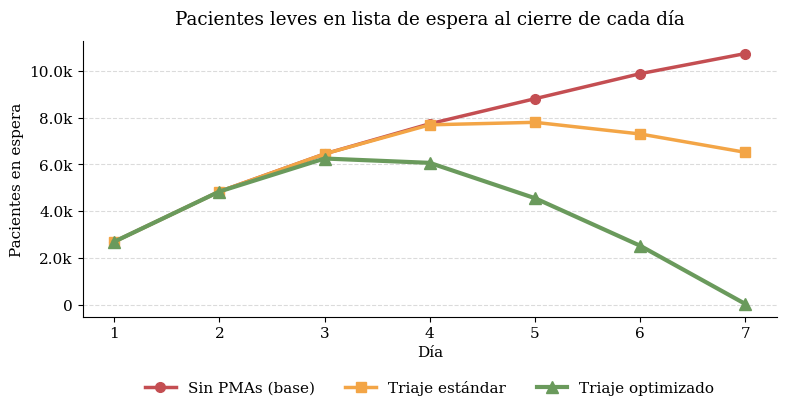

In [ ]:
def formato_abreviado(x, pos):
    if x >= 1e9:
        return f'{x/1e9:.1f}B'
    if x >= 1e6:
        return f'{x/1e6:.1f}M'
    if x >= 1e3:
        return f'{x/1e3:.1f}k'
    return f'{int(x):d}'


fig, ax = plt.subplots(figsize=(8, 4.8))

ax.plot(DIAS, base_esp_leve, marker="o", lw=2.5, ms=7,
        color=COLORES["base"], label="Sin PMAs (base)")
ax.plot(DIAS, h100["espera_leve"], marker="s", lw=2.5, ms=7,
        color=COLORES["h100"], label="Triaje estándar")
ax.plot(DIAS, h150["espera_leve"], marker="^", lw=3, ms=8,
        color=COLORES["h150"], label="Triaje optimizado")

ax.set_xlabel("Día")
ax.set_ylabel("Pacientes en espera")
ax.set_title("Pacientes leves en lista de espera al cierre de cada día", pad=12)
ax.set_xticks(DIAS)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(formato_abreviado))
ax.grid(axis="y", linestyle="--", alpha=0.45)
ax.legend(loc="upper center", bbox_to_anchor=(
    0.5, -0.18), ncol=3, frameon=False)

fig.tight_layout(rect=[0, 0.08, 1, 1])
fig.savefig(os.path.join(ROOT, "resultados", "graficos", "grafico_espera_leve.png"),
            dpi=150, bbox_inches="tight")
plt.show()

## 2 · Espera moderado por dia


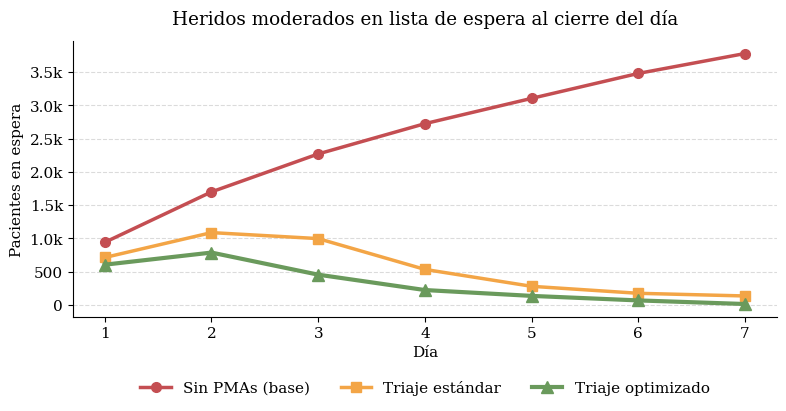

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(DIAS, base_esp_mod, marker="o", lw=2.5, ms=7,
        color=COLORES["base"], label="Sin PMAs (base)")
ax.plot(DIAS, h100["espera_moderado"], marker="s", lw=2.5, ms=7,
        color=COLORES["h100"], label="Triaje estándar")
ax.plot(DIAS, h150["espera_moderado"], marker="^", lw=3, ms=8,
        color=COLORES["h150"], label="Triaje optimizado")

ax.set_xlabel("Día")
ax.set_ylabel("Pacientes en espera")
ax.set_title("Heridos moderados en lista de espera al cierre del día", pad=12)
ax.set_xticks(DIAS)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(formato_abreviado))
ax.grid(axis="y", linestyle="--", alpha=0.45)
ax.legend(loc="upper center", bbox_to_anchor=(
    0.5, -0.18), ncol=3, frameon=False)

fig.tight_layout(rect=[0, 0.08, 1, 1])
fig.savefig(os.path.join(ROOT, "resultados", "graficos", "grafico_espera_moderado.png"),
            dpi=150, bbox_inches="tight")
plt.show()

## 3 · Centros activos por dia


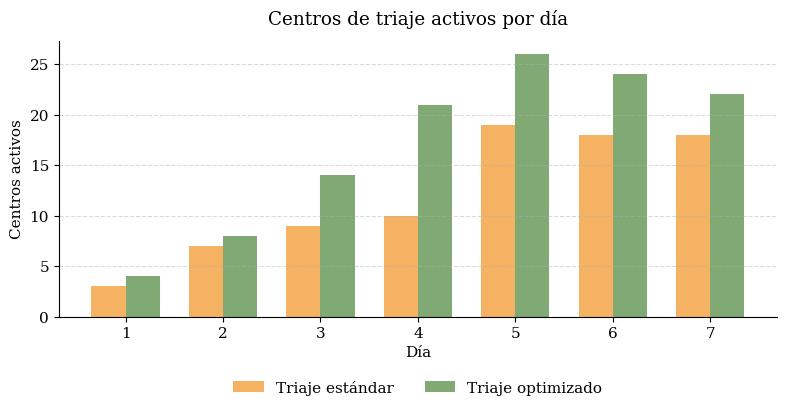

In [ ]:
x, w = np.arange(len(DIAS)), 0.35
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.bar(x - w/2, h100["centros_activos"], w,
       label="Triaje estándar", color=COLORES["h100"], alpha=0.85)
ax.bar(x + w/2, h150["centros_activos"], w,
       label="Triaje optimizado", color=COLORES["h150"], alpha=0.85)

ax.set_xlabel("Día")
ax.set_ylabel("Centros activos")
ax.set_title("Centros de triaje activos por día", pad=12)
ax.set_xticks(x)
ax.set_xticklabels(DIAS)
ax.grid(axis="y", linestyle="--", alpha=0.45)
ax.legend(loc="upper center", bbox_to_anchor=(
    0.5, -0.18), ncol=2, frameon=False)

fig.tight_layout(rect=[0, 0.08, 1, 1])
fig.savefig(os.path.join(ROOT, "resultados", "graficos", "grafico_centros.png"),
            dpi=150, bbox_inches="tight")
plt.show()

## 4 · Pacientes atendidos por dia


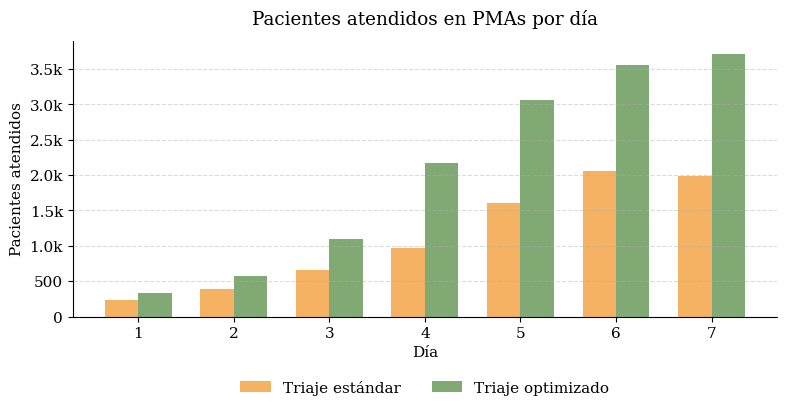

In [ ]:
x, w = np.arange(len(DIAS)), 0.35
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.bar(x - w/2, h100["pacientes_atendidos"], w,
       label="Triaje estándar", color=COLORES["h100"], alpha=0.85)
ax.bar(x + w/2, h150["pacientes_atendidos"], w,
       label="Triaje optimizado", color=COLORES["h150"], alpha=0.85)

ax.set_xlabel("Día")
ax.set_ylabel("Pacientes atendidos")
ax.set_title("Pacientes atendidos en PMAs por día", pad=12)
ax.set_xticks(x)
ax.set_xticklabels(DIAS)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(formato_abreviado))
ax.grid(axis="y", linestyle="--", alpha=0.45)
ax.legend(loc="upper center", bbox_to_anchor=(
    0.5, -0.18), ncol=2, frameon=False)

fig.tight_layout(rect=[0, 0.08, 1, 1])
fig.savefig(os.path.join(ROOT, "resultados", "graficos", "grafico_atendidos.png"),
            dpi=150, bbox_inches="tight")
plt.show()

## 5 · Tasa de atencion por categoria


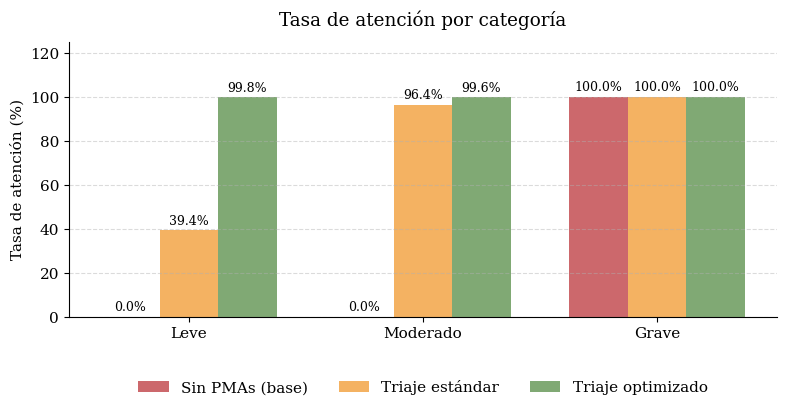

In [ ]:
def tasa(atend, total): return atend / total * 100 if total else 0


tasas_base = [0.0, 0.0, 100.0]
tasas_h100 = [tasa(DEM_LEVE - h100["espera_leve"][-1],    DEM_LEVE),
              tasa(DEM_MOD - h100["espera_moderado"][-1], DEM_MOD), 100.0]
tasas_h150 = [tasa(DEM_LEVE - h150["espera_leve"][-1],    DEM_LEVE),
              tasa(DEM_MOD - h150["espera_moderado"][-1], DEM_MOD), 100.0]
categorias = ["Leve", "Moderado", "Grave"]
x, w = np.arange(3), 0.25
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.bar(x - w, tasas_base, w, label="Sin PMAs (base)",
       color=COLORES["base"], alpha=0.85)
ax.bar(x,     tasas_h100, w, label="Triaje estándar",
       color=COLORES["h100"], alpha=0.85)
ax.bar(x + w, tasas_h150, w, label="Triaje optimizado",
       color=COLORES["h150"], alpha=0.85)

ax.set_ylabel("Tasa de atención (%)")
ax.set_title("Tasa de atención por categoría", pad=12)
ax.set_xticks(x)
ax.set_xticklabels(categorias)
ax.set_ylim(0, 125)
for bars in ax.containers:
    ax.bar_label(bars, fmt="%.1f%%", padding=2, fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.45)
ax.legend(loc="upper center", bbox_to_anchor=(
    0.5, -0.18), ncol=3, frameon=False)

fig.tight_layout(rect=[0, 0.08, 1, 1])
fig.savefig(os.path.join(ROOT, "resultados", "graficos", "grafico_tasas.png"),
            dpi=150, bbox_inches="tight")
plt.show()

## 6 · Funcion objetivo por escenario


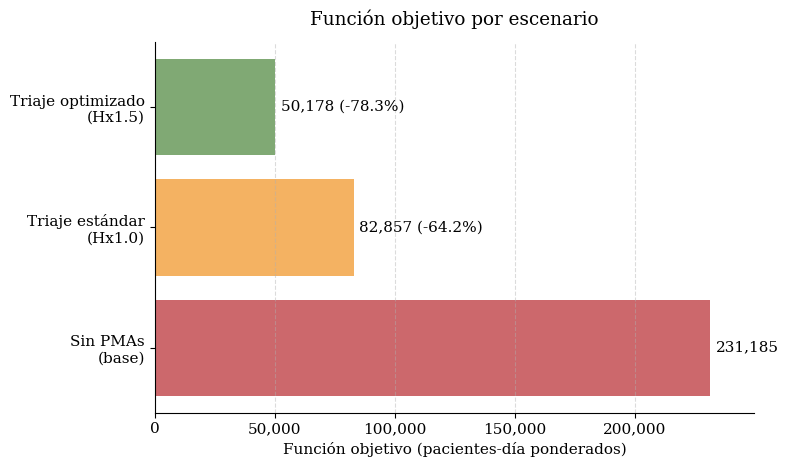

In [9]:
escenarios = [
    "Sin PMAs\n(base)",
    "Triaje estándar\n(Hx1.0)",
    "Triaje optimizado\n(Hx1.5)"
]

fo_vals = [fo_base, fo_h100, fo_h150]
colores = [COLORES["base"], COLORES["h100"], COLORES["h150"]]

red_h100 = (fo_base - fo_h100) / fo_base * 100
red_h150 = (fo_base - fo_h150) / fo_base * 100

fig, ax = plt.subplots(figsize=(8, 4.8))

bars = ax.barh(
    escenarios,
    fo_vals,
    color=colores,
    alpha=0.85
)

# Etiquetas con valor y mejora porcentual
labels = [
    f"{fo_base:,.0f}",
    f"{fo_h100:,.0f} (-{red_h100:.1f}%)",
    f"{fo_h150:,.0f} (-{red_h150:.1f}%)"
]

ax.bar_label(
    bars,
    labels=labels,
    padding=4
)

ax.set_xlabel("Función objetivo (pacientes-día ponderados)")
ax.set_title("Función objetivo por escenario", pad=12)

ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{int(x):,}")
)

# Ya no necesitas tanto espacio extra
ax.set_xlim(0, fo_base * 1.08)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.45
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()

fig.savefig(
    os.path.join(ROOT, "resultados", "graficos", "grafico_fo.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 7 · Graves atendidos en hospitales


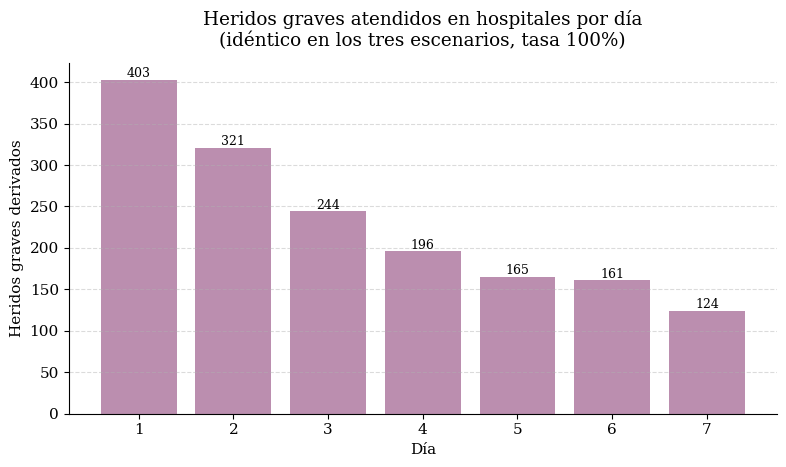

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.bar(DIAS, h100["graves_hospital"], color=COLORES["grave"], alpha=0.85)
ax.set_xlabel("Día")
ax.set_ylabel("Heridos graves derivados")
ax.set_title(
    "Heridos graves atendidos en hospitales por día\n(idéntico en los tres escenarios, tasa 100%)",
    pad=12)
ax.set_xticks(DIAS)
for i, v in enumerate(h100["graves_hospital"]):
    ax.text(DIAS[i], v + 3, str(v), ha="center", fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.45)

fig.tight_layout()
fig.savefig(os.path.join(ROOT, "resultados", "graficos", "grafico_graves.png"),
            dpi=150, bbox_inches="tight")
plt.show()

---

Gráficos guardados en `resultados/graficos/*.png`
